<a href="https://colab.research.google.com/github/NaoKB/EML/blob/main/k_brazos/UCB.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Bandido de k-brazos — UCB1

*Description:* El experimento compara el rendimiento de algoritmos UCB1 en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

## Algoritmos evaluados e hiperparámetros

### UCB1 (Auer et al., 2002)

Se evalúa **UCB1** variando la constante de exploración **c**:

$\displaystyle \mathrm{UCB}(a)=Q(a)+c\sqrt{\frac{\ln t}{N(a)}}$ siendo $c \in \{1,\sqrt{2},2\}$

## Preparación del entorno

In [2]:
!git clone https://github.com/NaoKB/EML.git
!cd EML/

fatal: destination path 'EML' already exists and is not an empty directory.


In [1]:
import sys
sys.path.append('/content/eml_k_bandit')

import numpy as np
from src.algorithms import UCB1
from src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from src.bandit_experiment import BanditExperiment

SEED = 42
np.random.seed(SEED)

## Experimento

In [3]:
k = 10; steps = 1000; runs = 500; n = 10
NORMAL_NAME = "normal" ; BERNOULLI_NAME = "bernoulli" ; BINOMIAL_NAME = "binomial"
algorithms = [UCB1(k=k, c=c) for c in [1.0, np.sqrt(2.0), 2.0]]

bandits = {
    NORMAL_NAME: Bandit(arms=ArmNormal.generate_arms(k)),
    BERNOULLI_NAME: Bandit(arms=ArmBernoulli.generate_arms(k)),
    BINOMIAL_NAME: Bandit(arms=ArmBinomial.generate_arms(k, n=n))
}

results = {name: BanditExperiment.run_experiment(bandit, algorithms, steps, runs) for name, bandit in bandits.items()}

## Ejecución del experimento

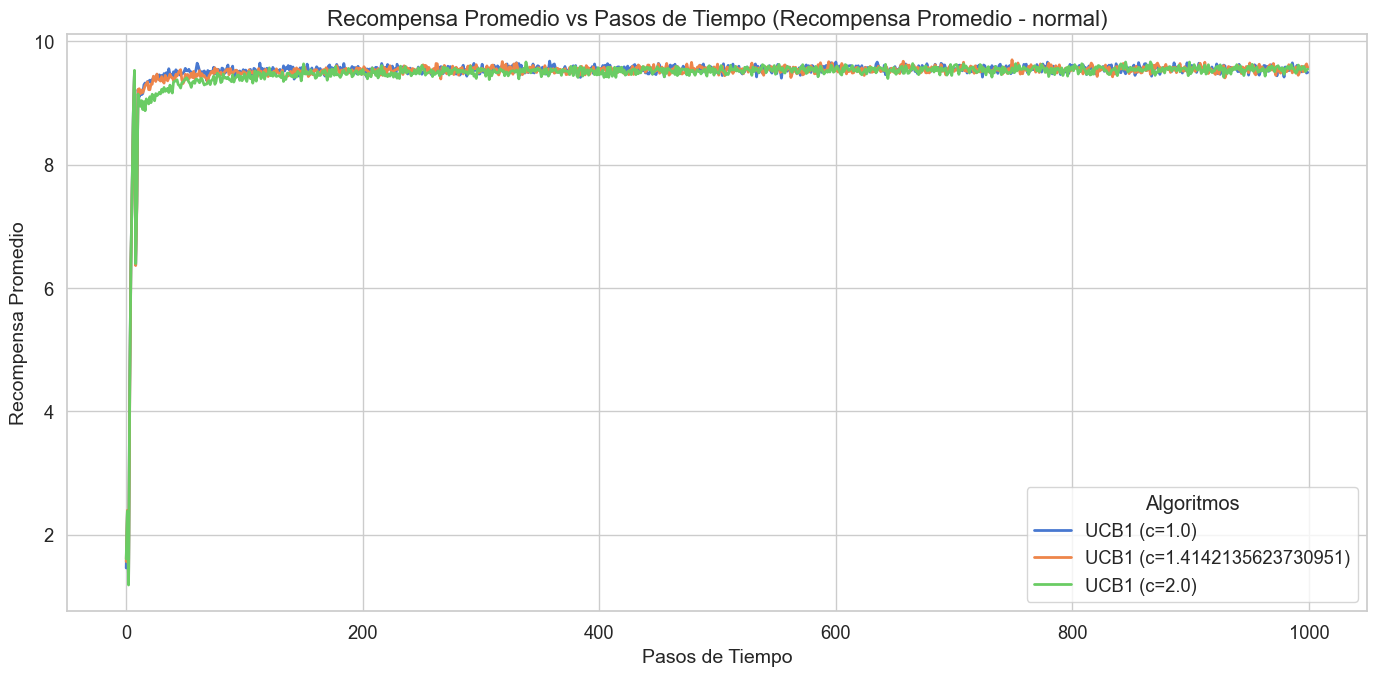

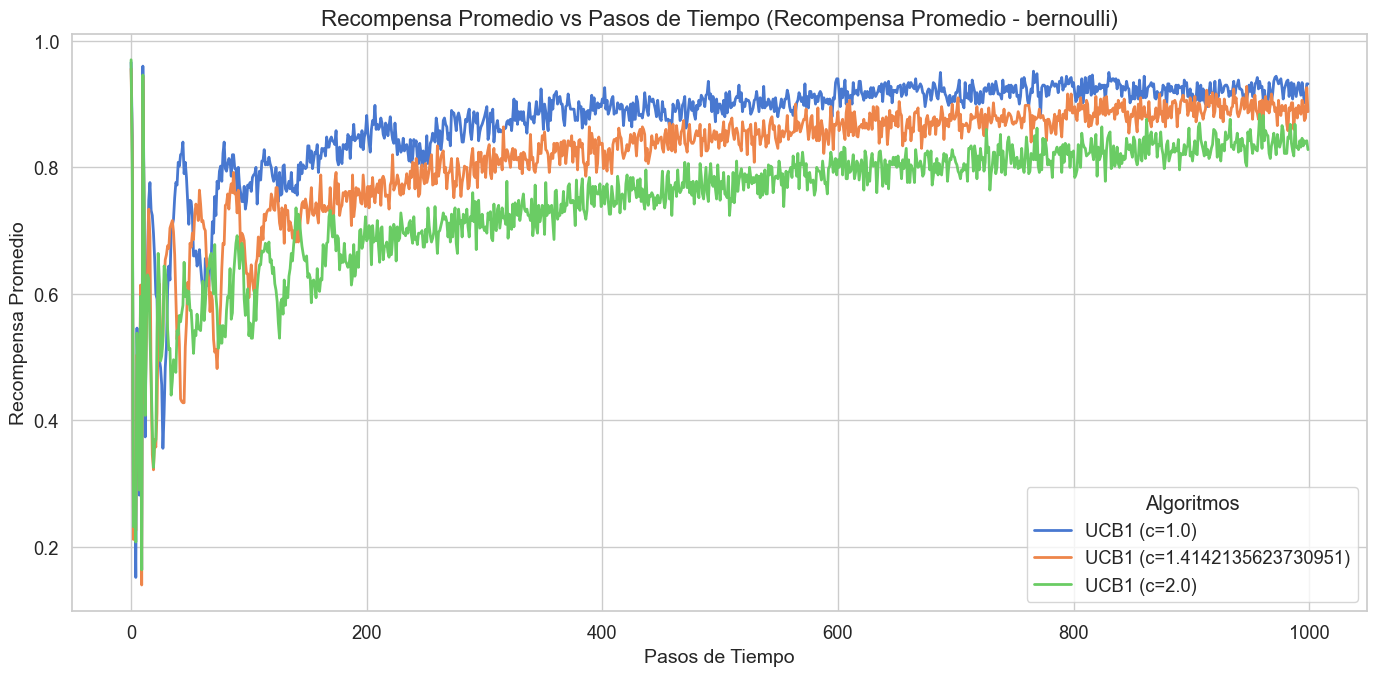

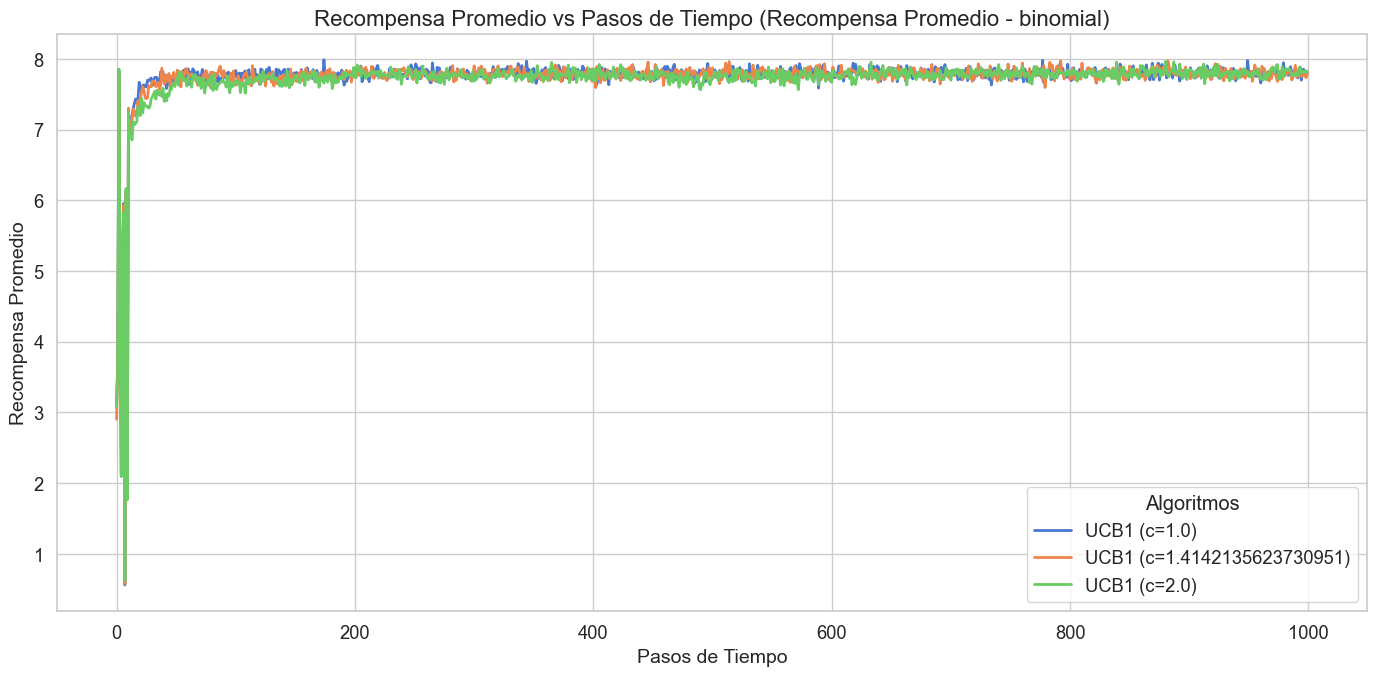

In [4]:
BanditExperiment.plot_rewards(results, steps, algorithms)

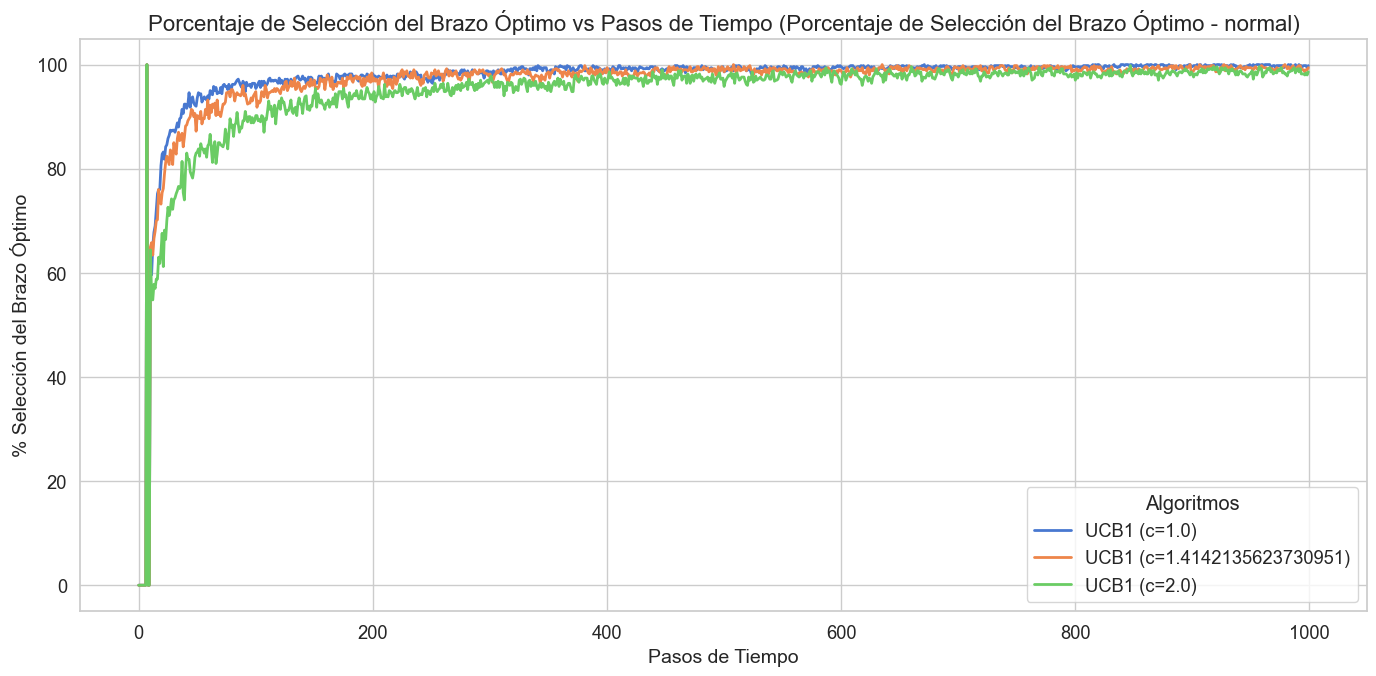

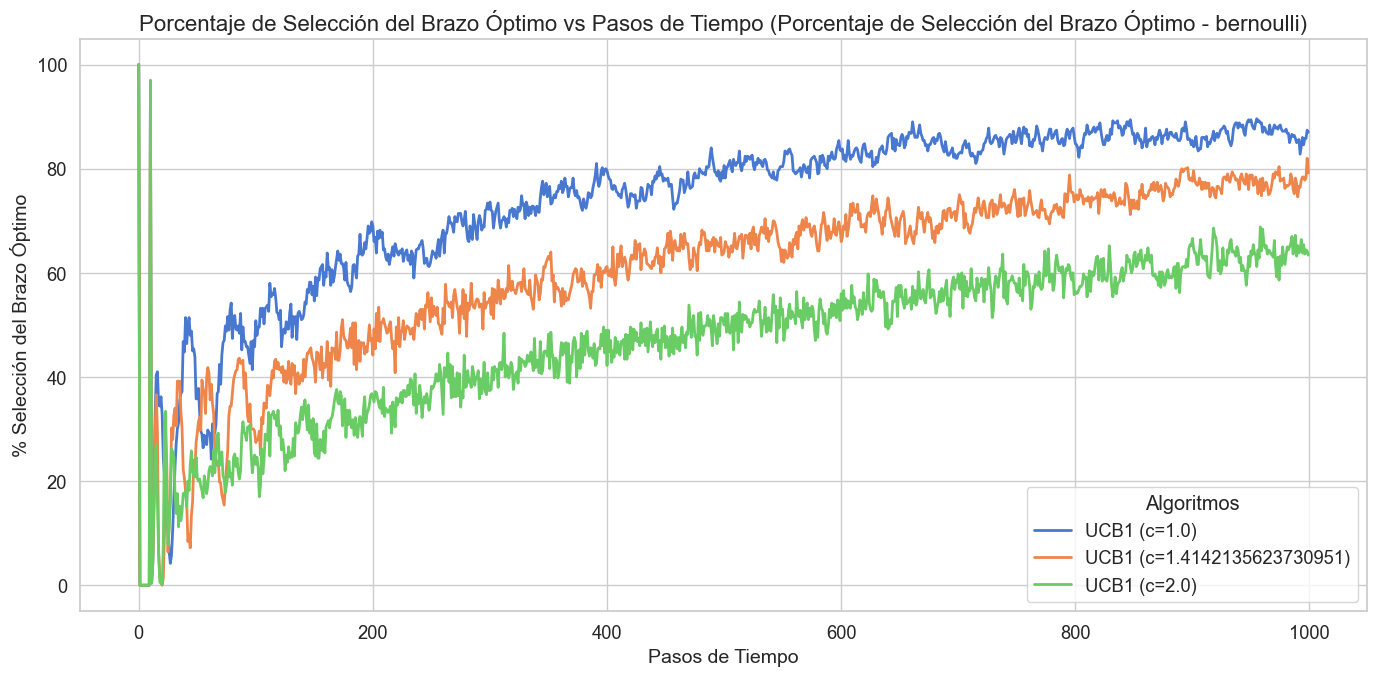

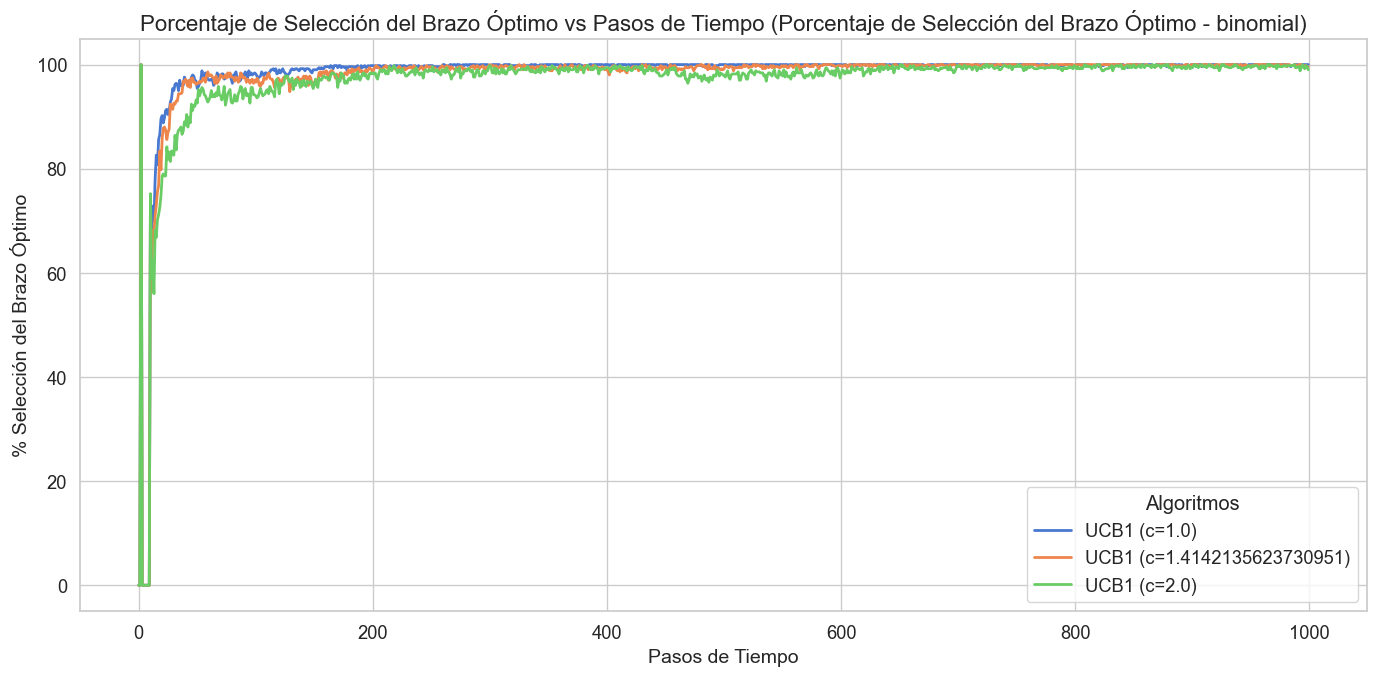

In [5]:
BanditExperiment.plot_optimal_selections(results, steps, algorithms)

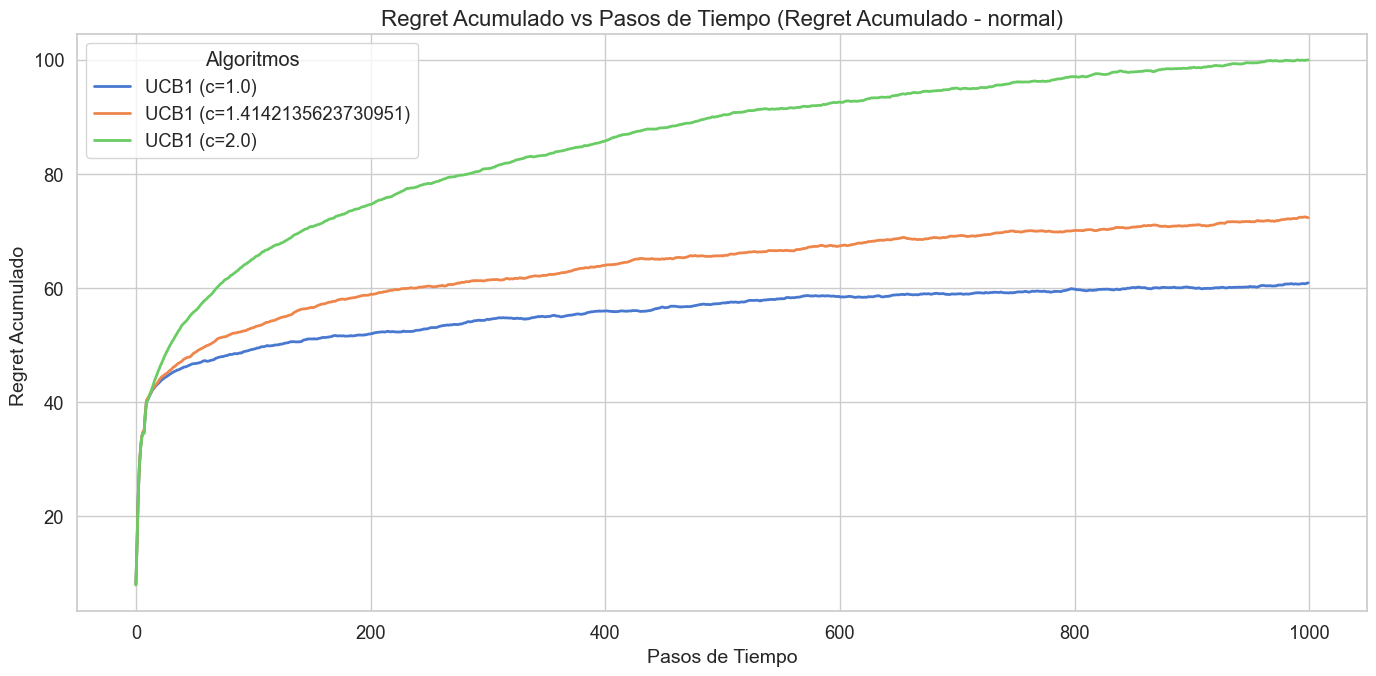

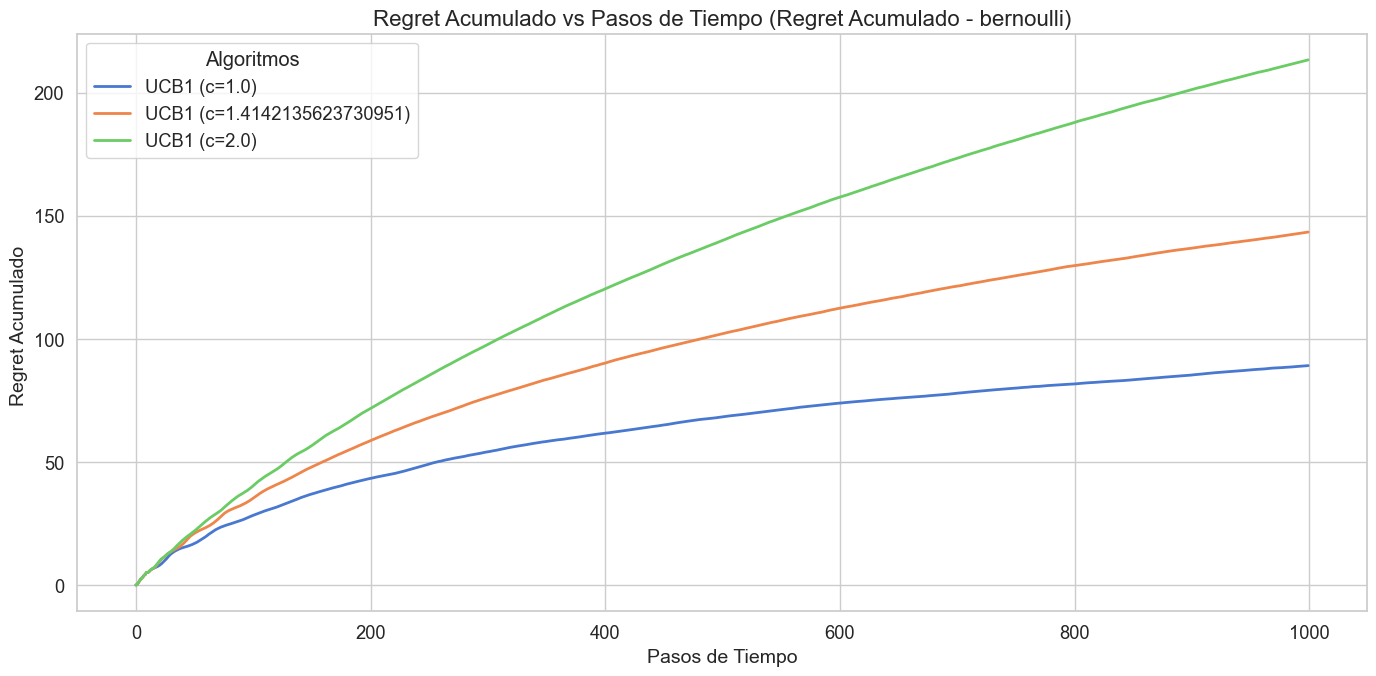

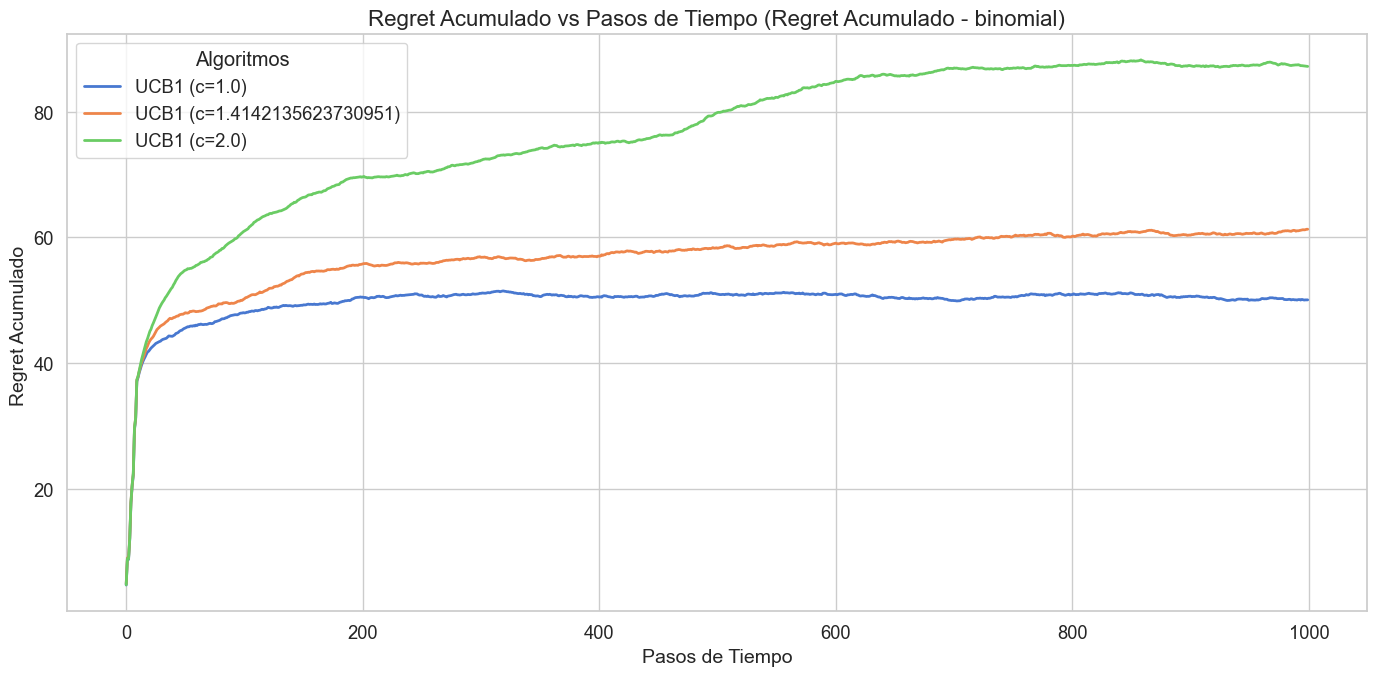

In [6]:
BanditExperiment.plot_regrets(results, steps, algorithms)

<Figure size 1400x700 with 0 Axes>

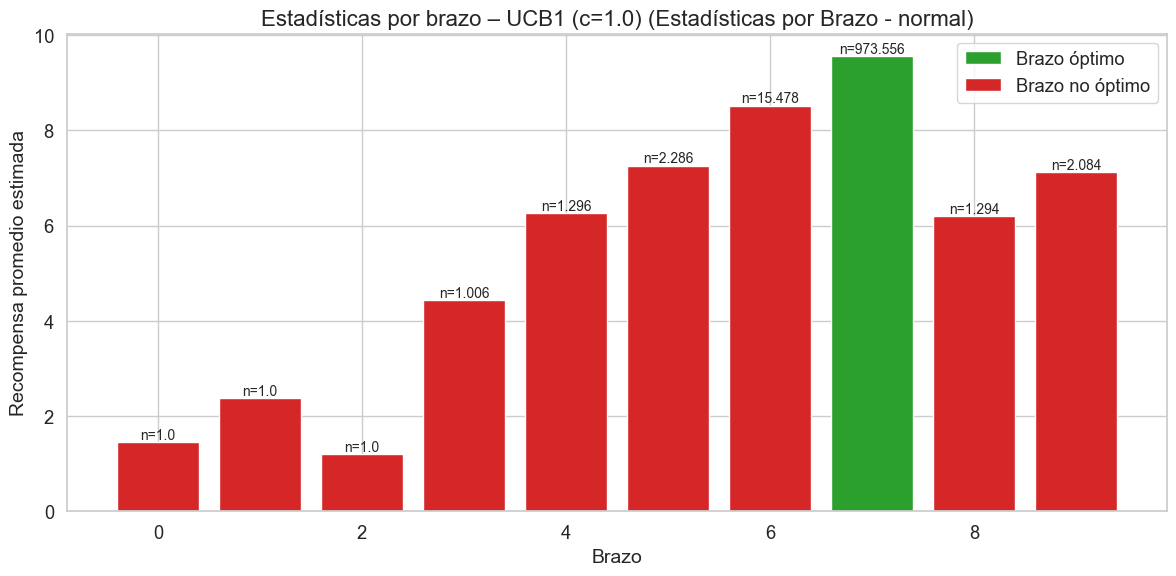

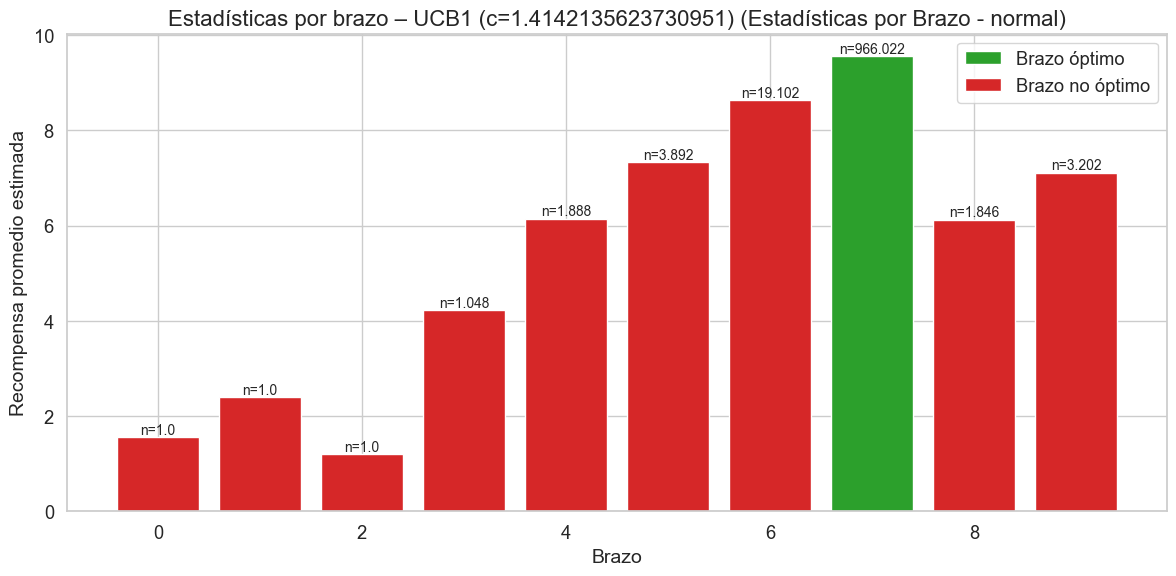

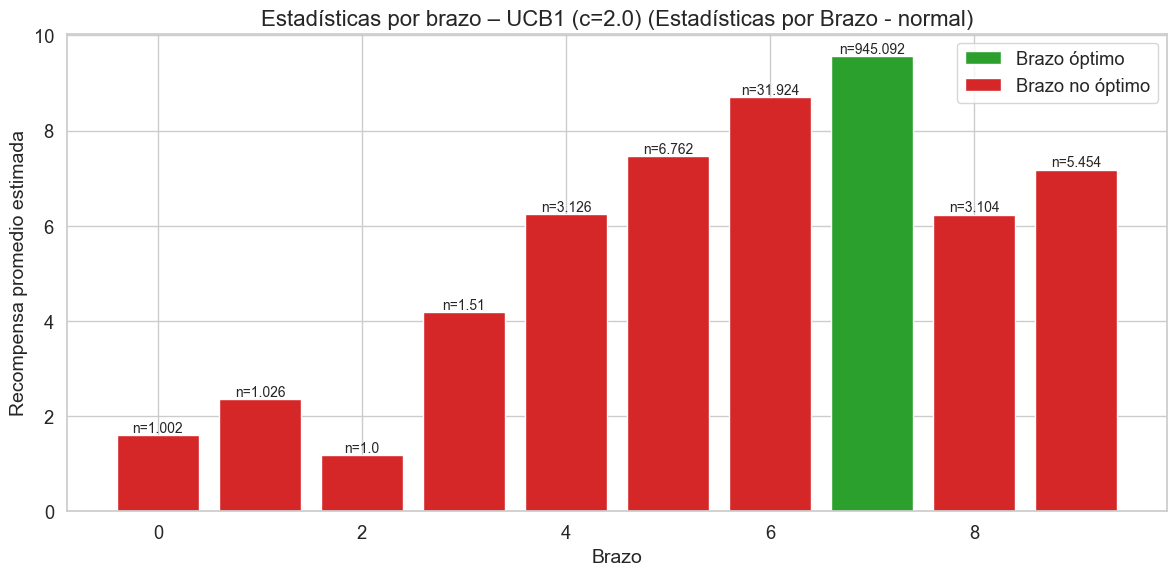

<Figure size 1400x700 with 0 Axes>

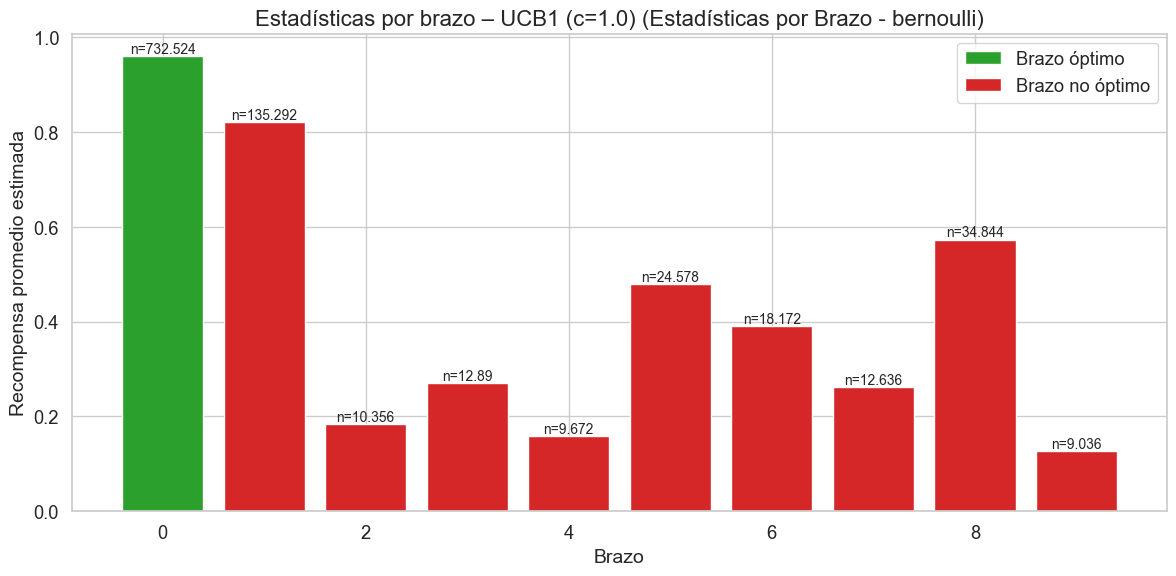

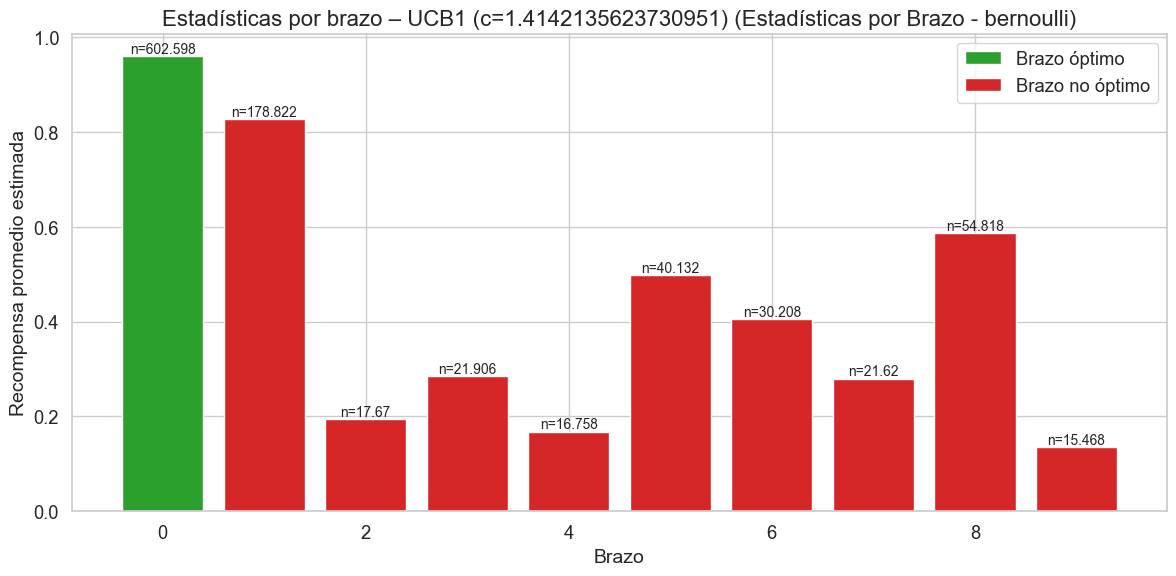

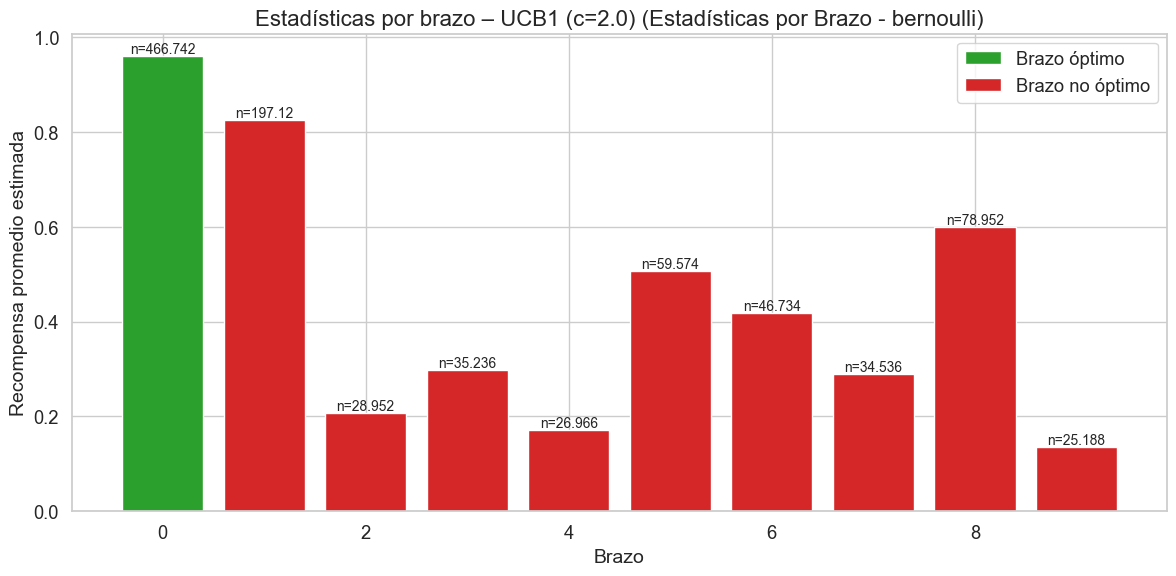

<Figure size 1400x700 with 0 Axes>

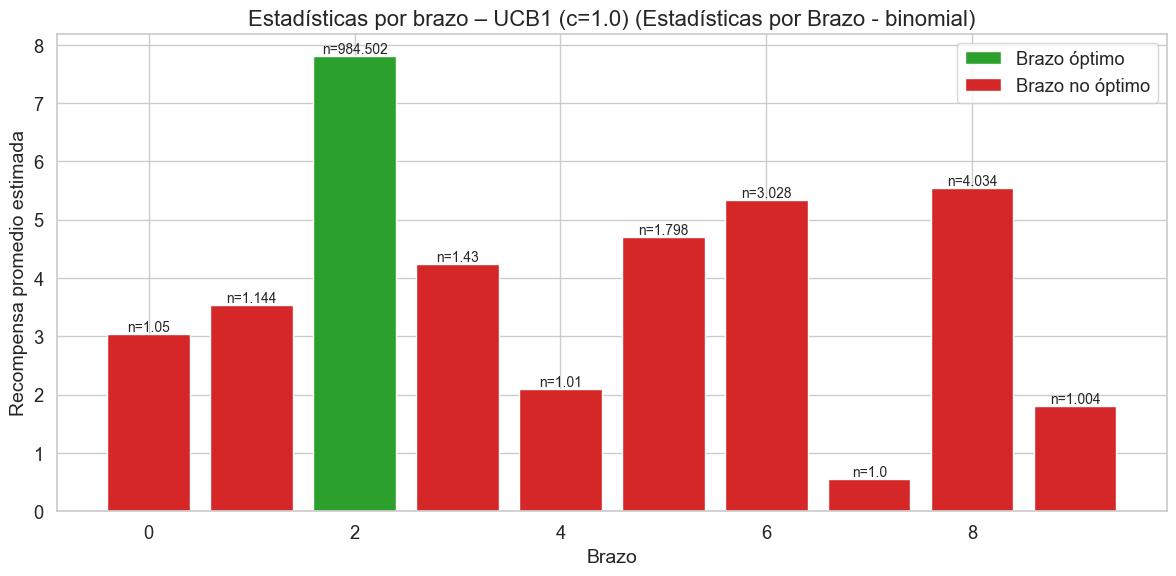

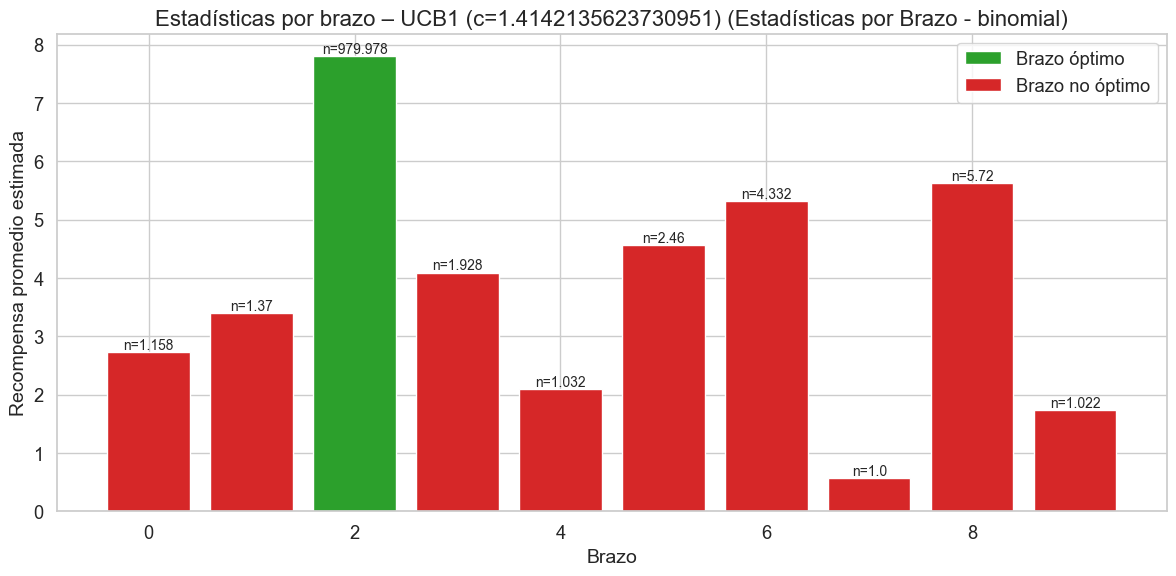

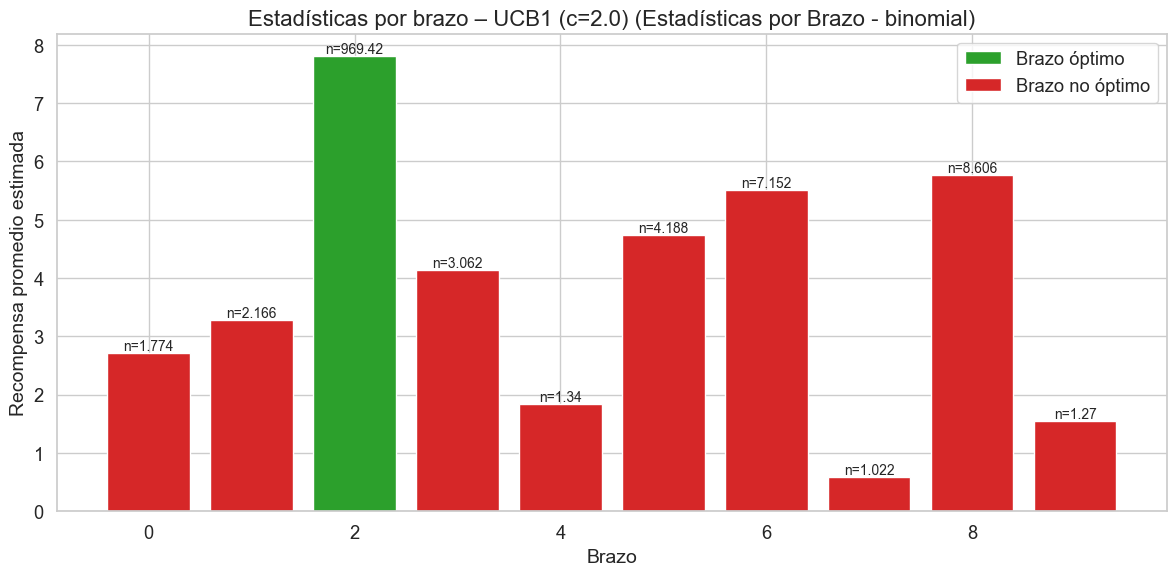

In [7]:
for name in [NORMAL_NAME,BERNOULLI_NAME,BINOMIAL_NAME]:
    BanditExperiment.plot_arm_statistics(bandits[name], results[name], algorithms, name)